In [9]:
import pypowsybl.network as pn
import math

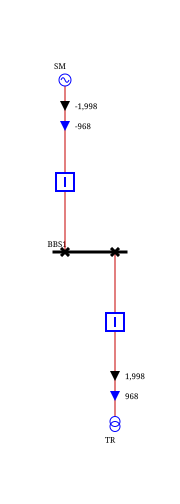

In [12]:
network = pn.create_empty(network_id='SMIB')

network.create_substations(id=['S1', 'S2'], name=['S1', 'S2'],  country=['FR', 'FR'], tso=["SMIB", "SMIB"])

network.create_voltage_levels(id='VL1', name='VL1', substation_id='S1', topology_kind='BUS_BREAKER',
                              nominal_v=1, low_voltage_limit=0.8, high_voltage_limit=1.2)
network.create_voltage_levels(id='VL2', name='VL2', substation_id='S2', topology_kind='BUS_BREAKER',
                              nominal_v=1, low_voltage_limit=0.8, high_voltage_limit=1.2)
network.create_voltage_levels(id='VL3', name='VL3', substation_id='S2', topology_kind='NODE_BREAKER',
                              nominal_v=1, low_voltage_limit=0.8, high_voltage_limit=1.2)

network.create_buses(id='VL1_BUS1', voltage_level_id='VL1')

network.create_buses(id='VL2_BUS1', voltage_level_id='VL2')

network.create_busbar_sections(id='BBS1', voltage_level_id='VL3', node=0)

network.create_switches(id='DS1', voltage_level_id='VL3', node1=0, node2=1, kind='DISCONNECTOR', open=False)
network.create_switches(id='BR1', voltage_level_id='VL3', node1=1, node2=2, kind='BREAKER', open=False)
network.create_switches(id='DS2', voltage_level_id='VL3', node1=0, node2=3, kind='DISCONNECTOR', open=False)
network.create_switches(id='BR2', voltage_level_id='VL3', node1=3, node2=4, kind='BREAKER', open=False)

network.create_lines(id='line1', voltage_level1_id='VL1', bus1_id='VL1_BUS1',
                     voltage_level2_id='VL2', bus2_id='VL2_BUS1',
                     b1=0, b2=0, g1=0, g2=0, r=0, x=0.022522)

network.create_lines(id='line2', voltage_level1_id='VL1', bus1_id='VL1_BUS1',
                     voltage_level2_id='VL2', bus2_id='VL2_BUS1',
                     b1=0, b2=0, g1=0, g2=0, r=0, x=0.04189)

network.create_2_windings_transformers(id='TR', voltage_level1_id='VL2', bus1_id='VL2_BUS1',
                                       voltage_level2_id='VL3', node2=4,
                                       b=0, g=0, r=0, x=0.00675, rated_u1=1, rated_u2=1)

network.create_generators(id='SM', voltage_level_id='VL3', node=2,
                          target_p=2200, min_p=0, max_p=2220, target_v=1, target_q=967.903359, energy_source='NUCLEAR',
                          voltage_regulator_on=True)

network.update_buses(id='VL1_0', v_mag=0.90081, v_angle=0)
network.update_buses(id='VL2_0', v_mag=1, v_angle=0.494451 * 180. / math.pi)
network.update_buses(id='VL3_0', v_mag=1, v_angle=0.494451 * 180. / math.pi)

SnRef = 100.
l1_p1 = -12.993888 * SnRef
l1_q1 = 0.563960 * SnRef
l1_p2 = 12.993888 * SnRef
l1_q2 = 4.131046 * SnRef
network.update_lines(id='line1', p1=l1_p1, q1=l1_q1, p2=l1_p2, q2=l1_q2)

l2_p1 = -6.986115 * SnRef
l2_q1 = 0.303211 * SnRef
l2_p2 = 6.986115 * SnRef
l2_q2 = 2.221041 * SnRef
network.update_lines(id='line2', p1=l2_p1, q1=l2_q1, p2=l2_p2, q2=l2_q2)

transformer_terminal1_V_re = 0.886710
transformer_terminal1_V_im = 0.324872
transformer_terminal1_i_re = -22.180041
transformer_terminal1_i_im = -0.962656

transformer_P1Pu = (transformer_terminal1_V_re * transformer_terminal1_i_re
                    + transformer_terminal1_V_im * transformer_terminal1_i_im) * SnRef
transformer_Q1Pu = (transformer_terminal1_V_im * transformer_terminal1_i_re
                    - transformer_terminal1_V_re * transformer_terminal1_i_im) * SnRef

transformer_terminal2_V_re = 0.880212
transformer_terminal2_V_im = 0.474588
transformer_terminal2_i_re = 22.180041
transformer_terminal2_i_im = 0.962656

transformer_P2Pu = (transformer_terminal2_V_re * transformer_terminal2_i_re
                    + transformer_terminal2_V_im * transformer_terminal2_i_im) * SnRef
transformer_Q2Pu = (transformer_terminal2_V_im * transformer_terminal2_i_re
                    - transformer_terminal2_V_re * transformer_terminal2_i_im) * SnRef

network.update_2_windings_transformers(id='TR', p1=transformer_P1Pu, q1=transformer_Q1Pu, p2=transformer_P2Pu, q2=transformer_Q2Pu)

network.update_generators(id='SM', p=-1998.000296, q=-967.903359)

network.get_single_line_diagram('VL3')